# ENGINE

# U-Net Denoising

# 0. Importaciones y Configuración

In [116]:
import sys
sys.path.append('../../src')

from astropy.io import fits
import torch
import torch.nn.functional as F
from u_net_model import UNet3D, UNet3DWithPadCrop
import numpy as np
import os
import matplotlib.pyplot as plt
import astropy.units as u
from radio_beam import Beams, Beam
from astropy.convolution import convolve, convolve_fft
from spectral_cube import SpectralCube

In [117]:
if torch.backends.mps.is_available():
    device = torch.device('mps')
elif torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

print(f'Dispositivo: {device}')

WEIGHTS_PATH = '/Users/kuky/Documents/practica/WALDO/weights/weights_best.pt'
DATA_DIR = '/Users/kuky/Documents/practica/WALDO/data'

Dispositivo: mps


## 0.1. Definición de Funciones

In [118]:
TRAINING_TARGET_SHAPE = (48, 96, 96)

def load_unet(weights_path, device, target_shape=TRAINING_TARGET_SHAPE):
    """Load U-Net with the same target_shape used during training.
    
    Parameters
    ----------
    weights_path : str
        Path to the saved model weights (.pt file).
    device : torch.device
        Device to load the model onto.
    target_shape : tuple of int, optional
        Fixed (D, H, W) used during training. Must match the shape the model
        was trained with so that internal feature scales are consistent.
        
    Returns
    -------
    model : UNet3DWithPadCrop
        Loaded model in eval mode. The wrapper handles padding/cropping
        automatically, so any input shape smaller than target_shape is valid.
    """
    base_model = UNet3D(n_channels=1, filters=16) # Estos valores están fijos por el entrenamiento realizado.
    model = UNet3DWithPadCrop(base_model, target_shape=target_shape)
    state_dict = torch.load(weights_path, map_location=device, weights_only=True)
    model.load_state_dict(state_dict)
    model.to(device)
    model.eval()
    return model


def denoising(cube, model, device):
    """Denoise by passing the cube directly through the bare UNet3D.
    
    Parameters
    ----------
    cube : np.ndarray
        Input cube (D, H, W) in original flux units.
        Must match the training target shape.
    model : UNet3DWithPadCrop
        Loaded model. Only ``model.unet`` (the inner UNet3D) is used.
    device : torch.device
    
    Returns
    -------
    np.ndarray
        Denoised cube in original flux units, same shape as input.
    """
    cube_mean, cube_std = cube.mean(), cube.std() # Se calculan la media y la desviación estándar de los datos.
    normalized = (cube - cube_mean) / cube_std # Se normaliza los datos. Esto es necesario debido a que el modelo fue entrenado con datos normalizados.

    tensor_in = torch.tensor(
        normalized[np.newaxis, np.newaxis, ...], dtype=torch.float32
    ).to(device) # Se convierte el cubo en un tensor y se mueve al dispositivo.

    with torch.no_grad():
        out = model.unet(tensor_in)

    return ((out * cube_std) + cube_mean)[0, 0].cpu().numpy() 

# 1. Carga de Modelo

In [10]:
model = load_unet(WEIGHTS_PATH, device) # Cargamos el modelo.

# 2. Elección Cubo

In [138]:
CUBE_TYPE_DIR = 'mock_cubes'
#CUBE_TYPE_DIR = 'real_cubes'

CUBE_DIR = 'isolated_sub_AC4_N50_width1'
#CUBE_DIR = 'condor01comb'
#CUBE_DIR = 'condor06ld'
#CUBE_DIR = 'pointingb'

CUBE_NAME = 'isolated_sub_AC4_N50_width1_noisy_sub_sub_52y148'
#CUBE_NAME = 'CONDOR01COMB_CO32_15kms_r05._subcube1'
#CUBE_NAME = 'CONDOR06LD_spw27_18kms_r05_subcube1'
#CUBE_NAME = 'PointingB_calibrated_SourceA_Contsub_CubeLine_Natural_50kms_image_subcube1_subcube'

# 3. Apertura Cubo

In [139]:
hdu = fits.open(os.path.join(DATA_DIR,CUBE_TYPE_DIR, CUBE_DIR, f'{CUBE_NAME}.fits'))
cube = np.squeeze(hdu[0].data)
cube = np.nan_to_num(cube, nan=0.0)

## 3.1. Revisión CUBE_SHAPE == TRUE

In [132]:
cube.shape

(86, 200, 200)

In [133]:
cube.shape == TRAINING_TARGET_SHAPE

False

Si **False**, debemos realizar un recorte antes de ingresar el cubo.

### *3.1.Optional. Recorte Cubo*

Vamos a tener al lado el cubo de referencia noisless para comprobar que no estemos recortando señal.

In [134]:
CUBE_NAME_REF = 'isolated_sub_AC4_N50_width1_notnoisy_sub'
hdu_ref = fits.open(os.path.join(DATA_DIR,CUBE_TYPE_DIR, CUBE_DIR, f'{CUBE_NAME_REF}.fits'))
cube_ref = np.squeeze(hdu_ref[0].data)
cube_ref = np.nan_to_num(cube_ref, nan=0.0)

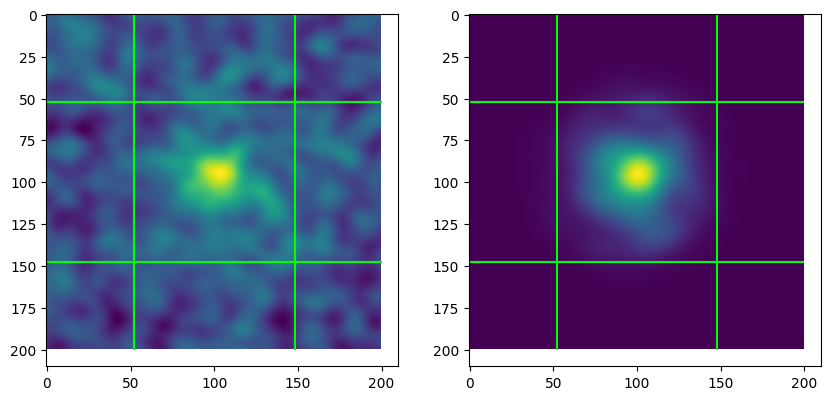

In [135]:
import matplotlib.colors as mpc

fig, axs = plt.subplots(1,2, figsize=(10,5))
axs[0].imshow(np.sum(cube[:,:,:], axis=0))

axs[0].vlines(52, 0, 200, color='lime')
axs[0].vlines(148, 0, 200, color='lime')
axs[0].hlines(52, 0, 200, color='lime')
axs[0].hlines(148, 0, 200, color='lime')


axs[1].imshow(np.sum(cube_ref[:,:,:], axis=0))
axs[1].vlines(52, 0, 200, color='lime')
axs[1].vlines(148, 0, 200, color='lime')
axs[1].hlines(52, 0, 200, color='lime')
axs[1].hlines(148, 0, 200, color='lime')

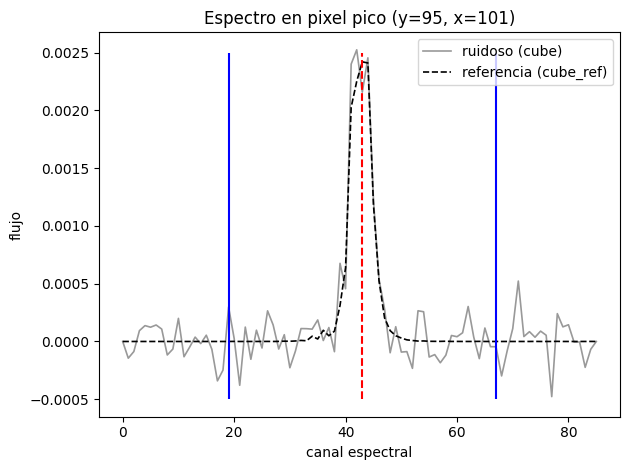

In [136]:
# Comparacion de curvas ESPECTRALES (perfil a lo largo del eje 0)
# Se elige el pixel mas brillante segun el flujo integrado del cubo de referencia.
flux_map = np.sum(cube_ref, axis=0)
y0, x0 = np.unravel_index(np.argmax(flux_map), flux_map.shape)

spec_cube_px = cube[:, y0, x0]
spec_ref_px = cube_ref[:, y0, x0]

chan = np.arange(cube.shape[0])


plt.plot(chan, spec_cube_px, color="0.6", lw=1.2, label="ruidoso (cube)")
plt.plot(chan, spec_ref_px, "k--", lw=1.2, label="referencia (cube_ref)")
plt.title(f"Espectro en pixel pico (y={y0}, x={x0})")
plt.xlabel("canal espectral")
plt.ylabel("flujo")
plt.legend()

plt.vlines(43, -0.0005, 0.0025, color='red', linestyle='--')
plt.vlines(67, -0.0005, 0.0025, color='blue')
plt.vlines(19, -0.0005, 0.0025, color='blue')

plt.tight_layout()
plt.show()

In [137]:
from astropy.wcs import WCS

y_lo, y_hi = 52, 148
x_lo, x_hi = 52, 148
spec_lo, spec_hi = 19, 67

# El cubo es 4D: numpy = (FREQ, STOKES, DEC, RA). Hay que slicear los 4 ejes
# (STOKES degenerado se deja completo con ':'). Usar 3 indices recortaria por
# error el eje STOKES y dejaria el subcubo vacio.
slices = (slice(spec_lo, spec_hi), slice(None), slice(y_lo, y_hi), slice(x_lo, x_hi))
subdata = hdu[0].data[slices]

# La WCS se recorta con el MISMO orden numpy; astropy reajusta CRPIX de TODOS
# los ejes (incluido el espectral, que aqui es CRPIX4=FREQ, no CRPIX3=STOKES).
wcs_sub = WCS(hdu[0].header)[slices]

# Copiamos el header del cubo original. Como astropy consume BSCALE/BZERO al
# aplicar el escalado en la lectura, los re-inyectamos para que el archivo
# resultante siga siendo válido para el resto del pipeline.
header = hdu[0].header.copy()
header.update(wcs_sub.to_header())
header['BSCALE'] = 1.0
header['BZERO']  = 0.0

new_hdu = fits.PrimaryHDU(data=subdata.astype(np.float32), header=header)

out_name = f'{CUBE_NAME}_sub_52y148.fits'
out_path = os.path.join(DATA_DIR, CUBE_TYPE_DIR, CUBE_DIR, out_name)
new_hdu.writeto(out_path, overwrite=True, output_verify='fix')

print('Saved:', out_name)
print('Shape:', subdata.shape)

Saved: isolated_sub_AC4_N50_width1_noisy_sub_sub_52y148.fits
Shape: (48, 1, 96, 96)


# 4. Denoising

## 4.1. Raw Denoising

In [140]:
denoised_raw = denoising(cube, model, device)

print(f'[Simple]        shape={denoised_raw.shape}  '
      f'rango=[{denoised_raw.min():.4e}, {denoised_raw.max():.4e}]')

out_path = os.path.join(DATA_DIR, CUBE_TYPE_DIR, CUBE_DIR, f'{CUBE_NAME}_unet_rawdenoise.fits')

# denoised_raw es 3D (FREQ, DEC, RA), pero el header original es 4D (incluye un
# eje STOKES degenerado). Guardar datos 3D con un header 4D deja la WCS
# inconsistente y CARTA no abre el archivo. Construimos un header 3D consistente
# quitando el eje STOKES (mismo cubo `hdu` del que salio `cube`).
from astropy.wcs import WCS

# Quitamos ejes STOKES (si existen) para dejar una WCS 3D (RA, DEC, FREQ)
# consistente con denoised_raw; funciona tanto si el header es 4D como 3D.
w = WCS(hdu[0].header)
stokes_axes = [i for i, t in enumerate(w.wcs.ctype) if 'STOKES' in t]
for ax in sorted(stokes_axes, reverse=True):
    w = w.dropaxis(ax)
header_out = w.to_header()
for k in ('BUNIT', 'BMAJ', 'BMIN', 'BPA', 'RESTFRQ', 'RESTFREQ', 'SPECSYS'):
    if k in hdu[0].header:
        header_out[k] = hdu[0].header[k]

hdu_out = fits.PrimaryHDU(denoised_raw.astype(np.float32), header=header_out)
hdu_out.writeto(out_path, overwrite=True, output_verify='fix')
print(f'Guardado: {out_path}')

[Simple]        shape=(48, 96, 96)  rango=[4.8746e-05, 2.2948e-03]
Guardado: /Users/kuky/Documents/practica/WALDO/data/mock_cubes/isolated_sub_AC4_N50_width1/isolated_sub_AC4_N50_width1_noisy_sub_sub_52y148_unet_rawdenoise.fits


#### 3.1.1.a Raw Denoising